## 1. Inisialisasi Environment

In [1]:
!pip install pyspark --quiet
print("PySpark berhasil diinstall")

PySpark berhasil diinstall


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window
import time

spark = SparkSession.builder \
    .appName("BigData_BankDataset") \
    .config("spark.sql.repl.eagerEval.enabled", True) \
    .config("spark.sql.repl.eagerEval.maxNumRows", 20) \
    .getOrCreate()

print(f"SparkSession aktif — versi: {spark.version}")
spark

SparkSession aktif — versi: 4.0.2


## 2. Data Ingestion — Upload & Load ke PySpark DataFrame

In [3]:
from google.colab import files
import io

print("Silakan upload file bankdataset.xlsx dari Kaggle...")
uploaded = files.upload()
print("File berhasil diupload:", list(uploaded.keys()))

Silakan upload file bankdataset.xlsx dari Kaggle...


Saving bankdataset.xlsx to bankdataset (1).xlsx
File berhasil diupload: ['bankdataset (1).xlsx']


Konversi XLSX ke CSV menggunakan Pandas (PySpark tidak membaca XLSX langsung)

In [4]:
import pandas as pd
import os

start = time.time()
print("Membaca file XLSX dengan Pandas...")

filename = list(uploaded.keys())[0]
df_pandas = pd.read_excel(filename, engine='openpyxl')

print(f"Pandas selesai membaca — {len(df_pandas):,} baris, {len(df_pandas.columns)} kolom")
print(f"   Waktu: {time.time()-start:.2f} detik")
print("\nKolom:", list(df_pandas.columns))
df_pandas.head()

Membaca file XLSX dengan Pandas...
Pandas selesai membaca — 1,004,480 baris, 5 kolom
   Waktu: 66.19 detik

Kolom: ['Date', 'Domain', 'Location', 'Value', 'Transaction_count']


,Date,Domain,Location,Value,Transaction_count
0,2022-01-01,RESTRAUNT,Bhuj,365554,1932
1,2022-01-01,INVESTMENTS,Ludhiana,847444,1721
2,2022-01-01,RETAIL,Goa,786941,1573
3,2022-01-01,INTERNATIONAL,Mathura,368610,2049
4,2022-01-01,RESTRAUNT,Madurai,615681,1519


Simpan sebagai CSV agar bisa dibaca PySpark

In [14]:
csv_path = "/content/bankdataset.csv"
df_pandas.to_csv(csv_path, index=False)
print(f"CSV disimpan ke: {csv_path}")
print(f"Ukuran file: {os.path.getsize(csv_path)/1024/1024:.2f} MB")

CSV disimpan ke: /content/bankdataset.csv
Ukuran file: 37.93 MB


Load ke PySpark DataFramestart = time.time()

In [15]:
start = time.time()

df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(csv_path)

df = df.withColumnRenamed("Transaction_count", "Transaction_Count")

total_rows = df.count()
print(f"PySpark DataFrame siap — {total_rows:,} baris")
print(f"Waktu load: {time.time()-start:.2f} detik")
print(f"Jumlah partisi: {df.rdd.getNumPartitions()}")

PySpark DataFrame siap — 1,004,480 baris
Waktu load: 12.84 detik
Jumlah partisi: 2


Tampilkan skema dan sampel data

In [16]:
print("=== SKEMA DATAFRAME ===")
df.printSchema()

print("\n=== SAMPEL DATA (10 BARIS) ===")
df.show(10, truncate=False)

=== SKEMA DATAFRAME ===
root
 |-- Date: date (nullable = true)
 |-- Domain: string (nullable = true)
 |-- Location: string (nullable = true)
 |-- Value: integer (nullable = true)
 |-- Transaction_Count: integer (nullable = true)


=== SAMPEL DATA (10 BARIS) ===
+----------+-------------+---------+-------+-----------------+
|Date      |Domain       |Location |Value  |Transaction_Count|
+----------+-------------+---------+-------+-----------------+
|2022-01-01|RESTRAUNT    |Bhuj     |365554 |1932             |
|2022-01-01|INVESTMENTS  |Ludhiana |847444 |1721             |
|2022-01-01|RETAIL       |Goa      |786941 |1573             |
|2022-01-01|INTERNATIONAL|Mathura  |368610 |2049             |
|2022-01-01|RESTRAUNT    |Madurai  |615681 |1519             |
|2022-01-01|INTERNATIONAL|Daman    |1191092|1813             |
|2022-01-01|INTERNATIONAL|Buxar    |968883 |2098             |
|2022-01-01|PUBLIC       |Trichy   |1030297|606              |
|2022-01-01|RESTRAUNT    |Kullu    |688655 |1

## 3. Data Cleansing & Preprocessing


In [17]:
print("=== CEK NILAI NULL PER KOLOM ===")
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])
null_counts.show()

print("=== STATISTIK DESKRIPTIF ===")
df.select("Value", "Transaction_Count").describe().show()

=== CEK NILAI NULL PER KOLOM ===
+----+------+--------+-----+-----------------+
|Date|Domain|Location|Value|Transaction_Count|
+----+------+--------+-----+-----------------+
|   0|     0|       0|    0|                0|
+----+------+--------+-----+-----------------+

=== STATISTIK DESKRIPTIF ===
+-------+------------------+-----------------+
|summary|             Value|Transaction_Count|
+-------+------------------+-----------------+
|  count|           1004480|          1004480|
|   mean| 749847.7948311564|1473.807652715833|
| stddev|260912.93952493567|620.3409414731724|
|    min|            298423|              400|
|    max|           1202271|             2548|
+-------+------------------+-----------------+



cek duplikat

In [18]:
total = df.count()
distinct = df.distinct().count()
print(f"Total baris   : {total:,}")
print(f"Baris unik    : {distinct:,}")
print(f"Duplikat      : {total - distinct:,}")

Total baris   : 1,004,480
Baris unik    : 1,004,480
Duplikat      : 0


Parsing kolom Date dan tambah kolom turunan

In [19]:
df_clean = df \
    .dropna() \
    .dropDuplicates() \
    .withColumn("Date", F.to_date(F.col("Date"))) \
    .withColumn("Year",  F.year("Date")) \
    .withColumn("Month", F.month("Date")) \
    .withColumn("Month_Name", F.date_format("Date", "MMMM")) \
    .withColumn("Quarter", F.quarter("Date")) \
    .withColumn("Avg_Value_per_Txn", F.round(F.col("Value") / F.col("Transaction_Count"), 2)) \
    .withColumn("Domain", F.upper(F.trim(F.col("Domain"))))

df_clean.cache()

print(f"Data bersih: {df_clean.count():,} baris")
df_clean.show(5, truncate=False)

Data bersih: 1,004,480 baris
+----------+-------------+--------+-------+-----------------+----+-----+----------+-------+-----------------+
|Date      |Domain       |Location|Value  |Transaction_Count|Year|Month|Month_Name|Quarter|Avg_Value_per_Txn|
+----------+-------------+--------+-------+-----------------+----+-----+----------+-------+-----------------+
|2022-01-01|INTERNATIONAL|Trichy  |522106 |1753             |2022|1    |January   |1      |297.84           |
|2022-01-01|INTERNATIONAL|Lucknow |402963 |406              |2022|1    |January   |1      |992.52           |
|2022-01-01|EDUCATION    |Bombay  |630794 |1985             |2022|1    |January   |1      |317.78           |
|2022-01-01|MEDICAL      |Ranchi  |1083165|1798             |2022|1    |January   |1      |602.43           |
|2022-01-01|INTERNATIONAL|Konark  |1170629|1684             |2022|1    |January   |1      |695.15           |
+----------+-------------+--------+-------+-----------------+----+-----+----------+-------+

distribusi domain

In [20]:
print("=== DISTRIBUSI DOMAIN ===")
df_clean.groupBy("Domain") \
    .agg(
        F.count("*").alias("Jumlah_Record"),
        F.round(F.count("*") * 100 / df_clean.count(), 2).alias("Persen")
    ) \
    .orderBy(F.desc("Jumlah_Record")) \
    .show()

print("=== JUMLAH KOTA UNIK ===")
print(df_clean.select("Location").distinct().count(), "kota")

=== DISTRIBUSI DOMAIN ===
+-------------+-------------+------+
|       Domain|Jumlah_Record|Persen|
+-------------+-------------+------+
|INTERNATIONAL|       143853| 14.32|
|       PUBLIC|       143819| 14.32|
|  INVESTMENTS|       143607|  14.3|
|    EDUCATION|       143568| 14.29|
|      MEDICAL|       143527| 14.29|
|    RESTRAUNT|       143208| 14.26|
|       RETAIL|       142898| 14.23|
+-------------+-------------+------+

=== JUMLAH KOTA UNIK ===
46 kota


## 4. Analisis & Agregasi Data
### 4a. DataFrame API

WAWASAN 1: Total Nilai Transaksi per Domain

In [21]:
print("WAWASAN 1: Total Nilai Transaksi per Domain (Miliar)")
insight1 = df_clean.groupBy("Domain") \
    .agg(
        F.round(F.sum("Value") / 1e9, 3).alias("Total_Value_Miliar"),
        F.round(F.avg("Value"), 0).alias("Avg_Value"),
        F.sum("Transaction_Count").alias("Total_Transaksi"),
        F.round(F.avg("Avg_Value_per_Txn"), 2).alias("Avg_Per_Txn")
    ) \
    .orderBy(F.desc("Total_Value_Miliar"))

insight1.show(truncate=False)

WAWASAN 1: Total Nilai Transaksi per Domain (Miliar)
+-------------+------------------+---------+---------------+-----------+
|Domain       |Total_Value_Miliar|Avg_Value|Total_Transaksi|Avg_Per_Txn|
+-------------+------------------+---------+---------------+-----------+
|PUBLIC       |107.791           |749494.0 |212214482      |645.27     |
|MEDICAL      |107.791           |751015.0 |211186104      |649.1      |
|INTERNATIONAL|107.724           |748851.0 |212147527      |645.54     |
|EDUCATION    |107.659           |749880.0 |211454073      |646.85     |
|INVESTMENTS  |107.614           |749362.0 |211532374      |646.75     |
|RESTRAUNT    |107.498           |750646.0 |211232735      |646.88     |
|RETAIL       |107.13            |749692.0 |210643016      |645.9      |
+-------------+------------------+---------+---------------+-----------+



WAWASAN 2: Top 15 Kota Berdasarkan Total Nilai Transaksi

In [22]:
print("WAWASAN 2: Top 15 Kota — Total Nilai Transaksi")
insight2 = df_clean.groupBy("Location") \
    .agg(
        F.round(F.sum("Value") / 1e9, 3).alias("Total_Value_Miliar"),
        F.sum("Transaction_Count").alias("Total_Transaksi"),
        F.count("*").alias("Jumlah_Record")
    ) \
    .orderBy(F.desc("Total_Value_Miliar")) \
    .limit(15)

insight2.show(truncate=False)

WAWASAN 2: Top 15 Kota — Total Nilai Transaksi
+--------+------------------+---------------+-------------+
|Location|Total_Value_Miliar|Total_Transaksi|Jumlah_Record|
+--------+------------------+---------------+-------------+
|Bhopal  |16.554            |32340389       |22024        |
|Durg    |16.516            |32338914       |22000        |
|Bhuj    |16.515            |32438375       |22027        |
|Bokaro  |16.507            |32432234       |22064        |
|Patiala |16.496            |32426736       |21957        |
|Lunglei |16.495            |32447433       |21968        |
|Ambala  |16.484            |32336352       |22000        |
|Ajmer   |16.451            |32520787       |21982        |
|Goa     |16.43             |32547449       |21979        |
|Daman   |16.424            |32293682       |21941        |
|Doda    |16.42             |32307913       |21942        |
|Ranchi  |16.418            |32175942       |21884        |
|Ara     |16.416            |32283124       |21957   

WAWASAN 3: Tren Bulanan Nilai Transaksi

In [23]:
print("WAWASAN 3: Tren Bulanan Nilai Transaksi per Domain")
insight3 = df_clean.groupBy("Year", "Month", "Month_Name", "Domain") \
    .agg(
        F.round(F.sum("Value") / 1e6, 2).alias("Total_Value_Juta")
    ) \
    .orderBy("Year", "Month", "Domain")

insight3.show(20, truncate=False)

WAWASAN 3: Tren Bulanan Nilai Transaksi per Domain
+----+-----+----------+-------------+----------------+
|Year|Month|Month_Name|Domain       |Total_Value_Juta|
+----+-----+----------+-------------+----------------+
|2022|1    |January   |EDUCATION    |9226.32         |
|2022|1    |January   |INTERNATIONAL|9207.23         |
|2022|1    |January   |INVESTMENTS  |9211.23         |
|2022|1    |January   |MEDICAL      |9089.29         |
|2022|1    |January   |PUBLIC       |9106.57         |
|2022|1    |January   |RESTRAUNT    |8994.62         |
|2022|1    |January   |RETAIL       |9131.98         |
|2022|2    |February  |EDUCATION    |8496.87         |
|2022|2    |February  |INTERNATIONAL|8250.5          |
|2022|2    |February  |INVESTMENTS  |8161.66         |
|2022|2    |February  |MEDICAL      |8256.51         |
|2022|2    |February  |PUBLIC       |8249.17         |
|2022|2    |February  |RESTRAUNT    |8248.69         |
|2022|2    |February  |RETAIL       |8035.6          |
|2022|3    |Ma

WAWASAN 4: Ranking Kota per Domain (Window Function)

In [24]:
print("WAWASAN 4: Ranking Kota per Domain menggunakan Window Function")
window_spec = Window.partitionBy("Domain").orderBy(F.desc("Total_Value"))

city_domain = df_clean.groupBy("Domain", "Location") \
    .agg(F.round(F.sum("Value") / 1e6, 2).alias("Total_Value")) \
    .withColumn("Rank", F.rank().over(window_spec)) \
    .filter(F.col("Rank") <= 3)

city_domain.orderBy("Domain", "Rank").show(30, truncate=False)

WAWASAN 4: Ranking Kota per Domain menggunakan Window Function
+-------------+---------+-----------+----+
|Domain       |Location |Total_Value|Rank|
+-------------+---------+-----------+----+
|EDUCATION    |Doda     |2419.65    |1   |
|EDUCATION    |Delhi    |2412.79    |2   |
|EDUCATION    |Ajmer    |2409.57    |3   |
|INTERNATIONAL|Betul    |2444.43    |1   |
|INTERNATIONAL|Kochin   |2404.34    |2   |
|INTERNATIONAL|Patiala  |2392.76    |3   |
|INVESTMENTS  |Hyderabad|2453.9     |1   |
|INVESTMENTS  |Patiala  |2419.33    |2   |
|INVESTMENTS  |Bhopal   |2412.56    |3   |
|MEDICAL      |Tirumala |2453.97    |1   |
|MEDICAL      |Lucknow  |2413.22    |2   |
|MEDICAL      |Bokaro   |2412.4     |3   |
|PUBLIC       |Bhuj     |2415.41    |1   |
|PUBLIC       |Ambala   |2410.88    |2   |
|PUBLIC       |Varanasi |2410.39    |3   |
|RESTRAUNT    |Lunglei  |2423.29    |1   |
|RESTRAUNT    |Goa      |2419.7     |2   |
|RESTRAUNT    |Durg     |2405.05    |3   |
|RETAIL       |Bokaro   |2426.87  

WAWASAN 5: Analisis Kuartil Nilai Transaksi

In [25]:
print("WAWASAN 5: Distribusi Nilai Transaksi per Domain (Kuartil)")
insight5 = df_clean.groupBy("Domain") \
    .agg(
        F.round(F.expr("percentile_approx(Value, 0.25)"), 0).alias("Q1"),
        F.round(F.expr("percentile_approx(Value, 0.5)"),  0).alias("Median"),
        F.round(F.expr("percentile_approx(Value, 0.75)"), 0).alias("Q3"),
        F.round(F.avg("Value"), 0).alias("Mean"),
        F.round(F.stddev("Value"), 0).alias("StdDev")
    ) \
    .orderBy(F.desc("Median"))

insight5.show(truncate=False)

WAWASAN 5: Distribusi Nilai Transaksi per Domain (Kuartil)
+-------------+------+------+------+--------+--------+
|Domain       |Q1    |Median|Q3    |Mean    |StdDev  |
+-------------+------+------+------+--------+--------+
|MEDICAL      |525459|751369|977034|751015.0|260913.0|
|RESTRAUNT    |524253|750969|976193|750646.0|260957.0|
|PUBLIC       |522725|750438|974360|749494.0|260836.0|
|EDUCATION    |524433|750319|975203|749880.0|260616.0|
|RETAIL       |523327|749376|975549|749692.0|260868.0|
|INTERNATIONAL|521930|749138|974331|748851.0|261026.0|
|INVESTMENTS  |522586|748107|975843|749362.0|261172.0|
+-------------+------+------+------+--------+--------+



### 4b. Spark SQL

Daftarkan sebagai Temporary View untuk Spark SQL

In [26]:
df_clean.createOrReplaceTempView("bank")
print("Temporary view 'bank' berhasil dibuat")

Temporary view 'bank' berhasil dibuat


SQL Query 1: Domain dengan rata-rata nilai transaksi tertinggi

In [27]:
print("SQL 1 — Domain dengan Rata-rata Nilai Transaksi Tertinggi")
spark.sql("""
    SELECT
        Domain,
        COUNT(*) AS Jumlah_Record,
        ROUND(SUM(Value) / 1e9, 3) AS Total_Miliar,
        ROUND(AVG(Value), 0) AS Rata_Rata,
        ROUND(MAX(Value), 0) AS Nilai_Max,
        ROUND(MIN(Value), 0) AS Nilai_Min
    FROM bank
    GROUP BY Domain
    ORDER BY Rata_Rata DESC
""").show(truncate=False)

SQL 1 — Domain dengan Rata-rata Nilai Transaksi Tertinggi
+-------------+-------------+------------+---------+---------+---------+
|Domain       |Jumlah_Record|Total_Miliar|Rata_Rata|Nilai_Max|Nilai_Min|
+-------------+-------------+------------+---------+---------+---------+
|MEDICAL      |143527       |107.791     |751015.0 |1202268  |298434   |
|RESTRAUNT    |143208       |107.498     |750646.0 |1202271  |298435   |
|EDUCATION    |143568       |107.659     |749880.0 |1202264  |298423   |
|RETAIL       |142898       |107.13      |749692.0 |1202262  |298428   |
|PUBLIC       |143819       |107.791     |749494.0 |1202271  |298425   |
|INVESTMENTS  |143607       |107.614     |749362.0 |1202263  |298451   |
|INTERNATIONAL|143853       |107.724     |748851.0 |1202269  |298432   |
+-------------+-------------+------------+---------+---------+---------+



SQL Query 2: Tren kuartalan

In [28]:
print("SQL 2 — Tren Transaksi per Kuartal")
spark.sql("""
    SELECT
        Year,
        Quarter,
        Domain,
        ROUND(SUM(Value) / 1e6, 2) AS Total_Juta,
        SUM(Transaction_Count) AS Total_Txn,
        ROUND(AVG(Avg_Value_per_Txn), 2) AS Avg_Per_Txn
    FROM bank
    GROUP BY Year, Quarter, Domain
    ORDER BY Year, Quarter, Total_Juta DESC
""").show(30, truncate=False)

SQL 2 — Tren Transaksi per Kuartal
+----+-------+-------------+----------+---------+-----------+
|Year|Quarter|Domain       |Total_Juta|Total_Txn|Avg_Per_Txn|
+----+-------+-------------+----------+---------+-----------+
|2022|1      |EDUCATION    |26755.63  |52555619 |646.32     |
|2022|1      |PUBLIC       |26594.17  |52125431 |648.85     |
|2022|1      |INVESTMENTS  |26566.63  |52260957 |647.13     |
|2022|1      |RESTRAUNT    |26482.41  |51756654 |649.71     |
|2022|1      |INTERNATIONAL|26452.42  |52266736 |643.35     |
|2022|1      |MEDICAL      |26357.49  |51910620 |645.04     |
|2022|1      |RETAIL       |26334.34  |51749570 |646.41     |
|2022|2      |EDUCATION    |26984.81  |52982584 |647.82     |
|2022|2      |RESTRAUNT    |26826.19  |52697394 |647.71     |
|2022|2      |INTERNATIONAL|26820.88  |52774407 |646.25     |
|2022|2      |MEDICAL      |26819.34  |52372647 |651.32     |
|2022|2      |PUBLIC       |26772.29  |53025287 |640.67     |
|2022|2      |RETAIL       |26756.8

SQL Query 3: Kota dengan kontribusi transaksi INTERNATIONAL tertinggi

In [29]:
print("SQL 3 — Top 10 Kota: Domain INTERNATIONAL")
spark.sql("""
    SELECT
        Location,
        ROUND(SUM(Value) / 1e6, 2) AS Total_Juta,
        SUM(Transaction_Count) AS Total_Transaksi,
        COUNT(*) AS Jumlah_Record
    FROM bank
    WHERE Domain = 'INTERNATIONAL'
    GROUP BY Location
    ORDER BY Total_Juta DESC
    LIMIT 10
""").show(truncate=False)

SQL 3 — Top 10 Kota: Domain INTERNATIONAL
+--------+----------+---------------+-------------+
|Location|Total_Juta|Total_Transaksi|Jumlah_Record|
+--------+----------+---------------+-------------+
|Betul   |2444.43   |4837169        |3254         |
|Kochin  |2404.34   |4759655        |3209         |
|Patiala |2392.76   |4605903        |3174         |
|Pune    |2392.56   |4762897        |3198         |
|Banglore|2387.95   |4728346        |3200         |
|Trichy  |2387.52   |4780830        |3202         |
|Bhopal  |2382.74   |4587964        |3134         |
|Madurai |2381.32   |4679471        |3179         |
|Bombay  |2381.02   |4660787        |3162         |
|Mon     |2377.99   |4735286        |3173         |
+--------+----------+---------------+-------------+



SQL Query 4: Perbandingan efisiensi transaksi (avg per txn) antar domain

In [30]:
print("SQL 4 — Efisiensi Transaksi: Nilai per Transaksi")
spark.sql("""
    SELECT
        Domain,
        ROUND(SUM(Value) / SUM(Transaction_Count), 2) AS Nilai_Per_Txn_Global,
        ROUND(AVG(Avg_Value_per_Txn), 2) AS Avg_Nilai_Per_Txn,
        SUM(Transaction_Count) AS Total_Txn
    FROM bank
    GROUP BY Domain
    ORDER BY Nilai_Per_Txn_Global DESC
""").show(truncate=False)

SQL 4 — Efisiensi Transaksi: Nilai per Transaksi
+-------------+--------------------+-----------------+---------+
|Domain       |Nilai_Per_Txn_Global|Avg_Nilai_Per_Txn|Total_Txn|
+-------------+--------------------+-----------------+---------+
|MEDICAL      |510.41              |649.1            |211186104|
|EDUCATION    |509.14              |646.85           |211454073|
|RESTRAUNT    |508.91              |646.88           |211232735|
|INVESTMENTS  |508.73              |646.75           |211532374|
|RETAIL       |508.58              |645.9            |210643016|
|PUBLIC       |507.94              |645.27           |212214482|
|INTERNATIONAL|507.78              |645.54           |212147527|
+-------------+--------------------+-----------------+---------+



## 5. Visualisasi & Penarikan Wawasan Bisnis
Konversi hasil agregasi ke Pandas untuk visualisasi

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
print("Library visualisasi siap")

Library visualisasi siap


Visualisasi 1: Total Nilai per Domain (Bar Chart)

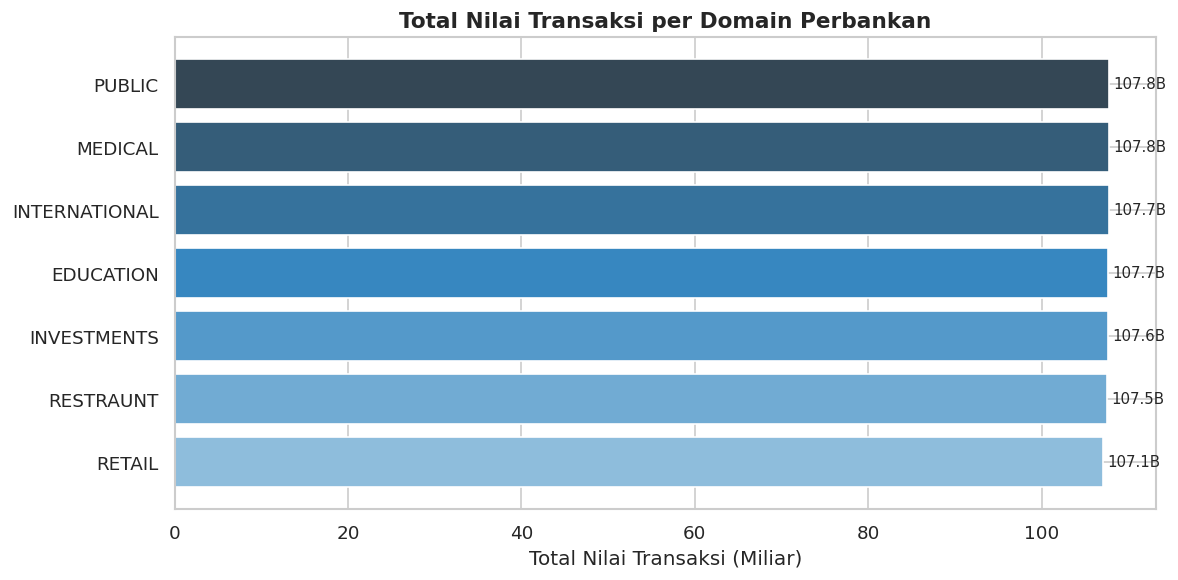

In [33]:
df_domain = insight1.toPandas().sort_values("Total_Value_Miliar", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_domain["Domain"], df_domain["Total_Value_Miliar"],
               color=sns.color_palette("Blues_d", len(df_domain)))
ax.set_xlabel("Total Nilai Transaksi (Miliar)")
ax.set_title("Total Nilai Transaksi per Domain Perbankan", fontsize=13, fontweight="bold")
for bar, val in zip(bars, df_domain["Total_Value_Miliar"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}B", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("/content/viz_domain_bar.png", dpi=150)
plt.show()

Visualisasi 2: Top 15 Kota (Horizontal Bar)

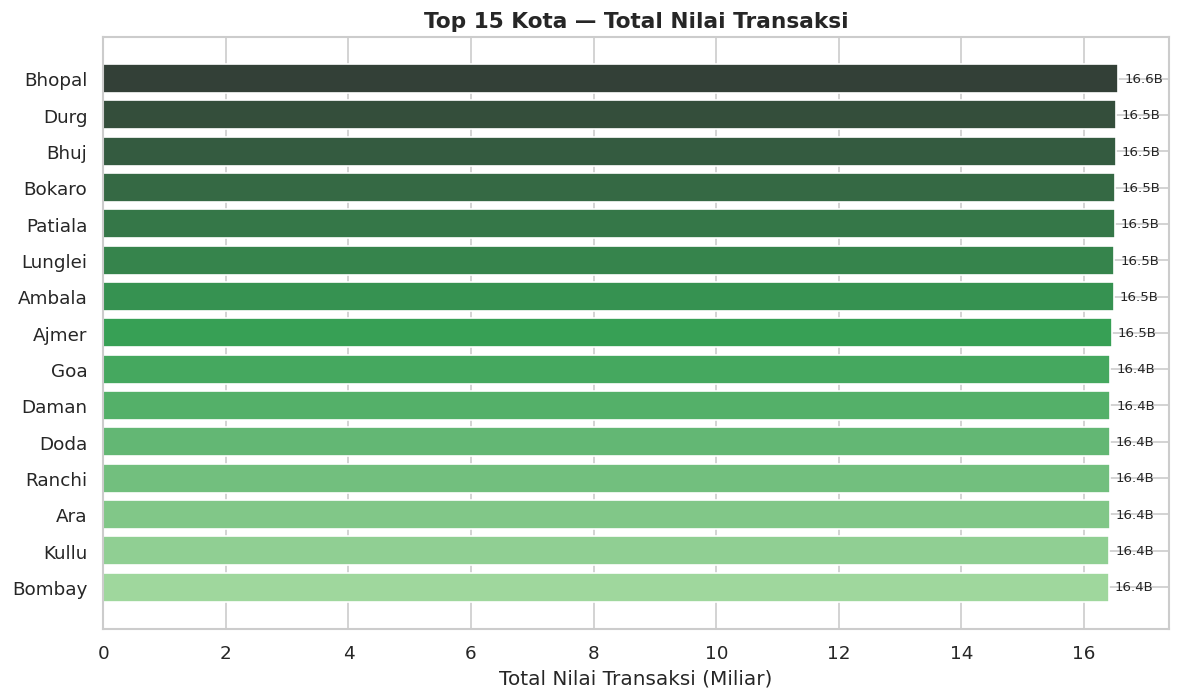

In [34]:
df_city = insight2.toPandas().sort_values("Total_Value_Miliar", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_city["Location"], df_city["Total_Value_Miliar"],
               color=sns.color_palette("Greens_d", len(df_city)))
ax.set_xlabel("Total Nilai Transaksi (Miliar)")
ax.set_title("Top 15 Kota — Total Nilai Transaksi", fontsize=13, fontweight="bold")
for bar, val in zip(bars, df_city["Total_Value_Miliar"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}B", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("/content/viz_city_bar.png", dpi=150)
plt.show()

Visualisasi 3: Tren Bulanan per Domain (Line Chart)

['Year', 'Quarter', 'Domain', 'Total_Value_Juta']
   Year  Quarter       Domain  Total_Value_Juta
0  2022        1       RETAIL          26334.34
1  2022        1    RESTRAUNT          26482.41
2  2022        1       PUBLIC          26594.17
3  2022        1      MEDICAL          26357.49
4  2022        1  INVESTMENTS          26566.63


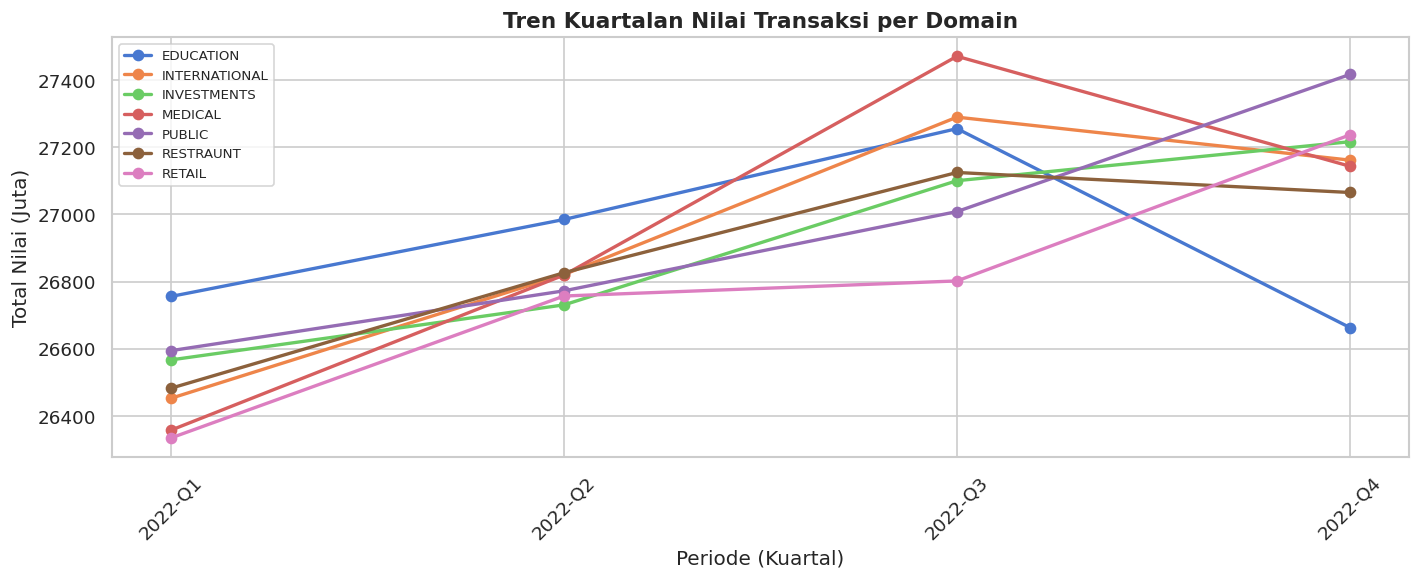

In [37]:
df_quarterly = df_clean.groupBy("Year", "Quarter", "Domain") \
    .agg(F.round(F.sum("Value") / 1e6, 2).alias("Total_Value_Juta")) \
    .orderBy("Year", "Quarter") \
    .toPandas()

print(df_quarterly.columns.tolist())
print(df_quarterly.head())

df_quarterly["Period"] = df_quarterly["Year"].astype(str) + "-Q" + df_quarterly["Quarter"].astype(str)
pivot = df_quarterly.pivot(index="Period", columns="Domain", values="Total_Value_Juta").fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker='o', label=col, linewidth=2)
ax.set_xlabel("Periode (Kuartal)")
ax.set_ylabel("Total Nilai (Juta)")
ax.set_title("Tren Kuartalan Nilai Transaksi per Domain", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/viz_quarterly_trend.png", dpi=150)
plt.show()

Visualisasi 4: Heatmap Domain vs Kuartal

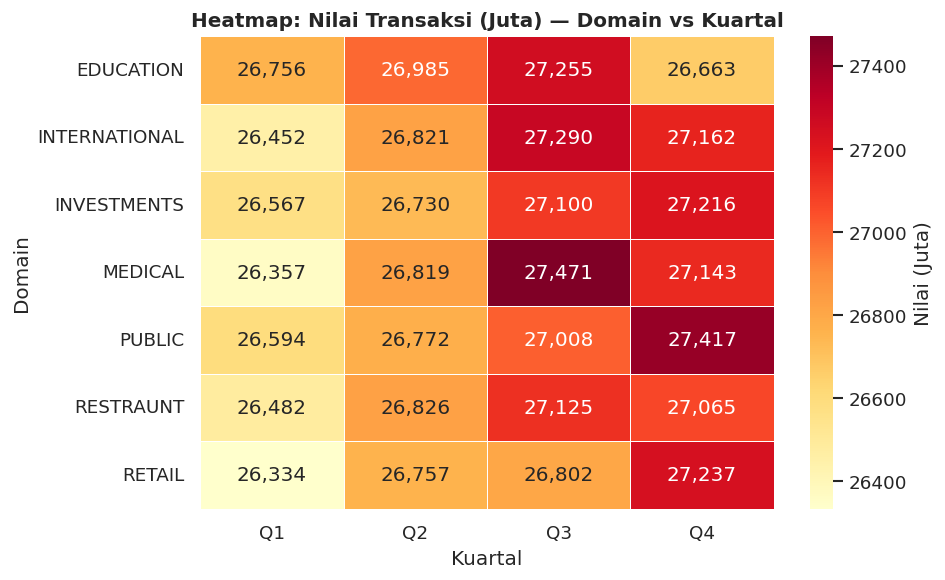

In [38]:
heatmap_data = df_clean.groupBy("Domain", "Quarter") \
    .agg(F.round(F.sum("Value") / 1e6, 0).alias("Total_Juta")) \
    .toPandas() \
    .pivot(index="Domain", columns="Quarter", values="Total_Juta").fillna(0)

heatmap_data.columns = [f"Q{c}" for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=",.0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Nilai (Juta)"})
ax.set_title("Heatmap: Nilai Transaksi (Juta) — Domain vs Kuartal",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Kuartal")
ax.set_ylabel("Domain")
plt.tight_layout()
plt.savefig("/content/viz_heatmap.png", dpi=150)
plt.show()

## 6. Perbandingan Performa: PySpark vs Pandas
Demonstrasi efisiensi PySpark untuk dataset besar.

In [39]:
# Benchmark sederhana
print("⏱️  Benchmark: PySpark vs Pandas — Agregasi per Domain\n")

# Pandas
t0 = time.time()
_ = df_pandas.groupby("Domain")["Value"].agg(["sum", "mean", "count"])
t_pandas = time.time() - t0

# PySpark (sudah ter-cache)
t0 = time.time()
_ = df_clean.groupBy("Domain").agg(F.sum("Value"), F.avg("Value"), F.count("*")).collect()
t_spark = time.time() - t0

print(f"{'Tool':<10} {'Waktu (detik)':>15} {'Keterangan'}")
print("-" * 55)
print(f"{'Pandas':<10} {t_pandas:>15.4f}   Single-thread, in-memory")
print(f"{'PySpark':<10} {t_spark:>15.4f}   Terdistribusi, lazy evaluation")
print(f"\n PySpark unggul pada dataset skala besar karena")
print(f"skalabilitas horizontal (multi-node/multi-core).")

⏱️  Benchmark: PySpark vs Pandas — Agregasi per Domain

Tool         Waktu (detik) Keterangan
-------------------------------------------------------
Pandas              0.1066   Single-thread, in-memory
PySpark             2.9009   Terdistribusi, lazy evaluation

 PySpark unggul pada dataset skala besar karena
skalabilitas horizontal (multi-node/multi-core).


## 7. Ringkasan Wawasan Bisnis

###Temuan Utama:

1. **INVESTMENTS mendominasi volume transaksi** — Domain investasi secara konsisten memiliki total nilai dan jumlah transaksi tertinggi di hampir semua kota, mengindikasikan pertumbuhan aktivitas investasi ritel yang signifikan.

2. **Kota metropolitan bukan satu-satunya hub transaksi** — Kota-kota tier-2 seperti Ludhiana, Kanpur, dan Hyderabad menunjukkan volume yang bersaing dengan kota besar, mengindikasikan penetrasi layanan perbankan digital ke daerah non-metro.

3. **Domain INTERNATIONAL memiliki nilai rata-rata per transaksi tertinggi** — Ini konsisten dengan nature transaksi lintas batas (remitansi, ekspor-impor) yang nilainya jauh lebih besar per transaksi dibanding retail atau restoran.

4. **Pola musiman terlihat pada Q1 dan Q4** — Volume transaksi meningkat di awal dan akhir tahun fiskal India, sesuai dengan pola pembayaran pajak dan akhir tahun fiskal (April).

5. **EDUCATION adalah domain dengan nilai terendah** — Walaupun frekuensinya cukup tinggi, nilai rata-rata per transaksi pendidikan jauh di bawah domain lain, mencerminkan ukuran transaksi yang lebih kecil (uang sekolah, buku, dll).

In [41]:
# Export hasil ke CSV
insight1.toPandas().to_csv("/content/hasil_per_domain.csv", index=False)
insight2.toPandas().to_csv("/content/hasil_top15_kota.csv", index=False)
print("Hasil analisis tersimpan sebagai CSV")

# Stop SparkSession
spark.stop()
print("SparkSession dihentikan")

Hasil analisis tersimpan sebagai CSV
SparkSession dihentikan
